<a href="https://colab.research.google.com/github/AaryaaShaarmaa/Ai-bootcamp/blob/main/Stroke_Data_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:
df = pd.read_csv(
    "https://raw.githubusercontent.com/AaryaaShaarmaa/Ai-bootcamp/main/healthcare-dataset-stroke-data.csv"
)

In [99]:
df.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [100]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


Here i spot that my age column is in float type which is unnecessary so i change it to integer values

In [101]:
df["age"] = df["age"].round().astype(int) #I round off the float values too using round()
#NOTE: data types can only be changed if the column doesnt have any null values

In [102]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   int64  
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(2), int64(5), object(5)
memory usage: 479.2+ KB


In [103]:
df.isnull().sum().sort_values(ascending=True)

,0
id,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
smoking_status,0


since bmi has 201 missing values which is not that much i will replace those missing values with median of all 5000+ values given in data set

In [148]:
df["bmi"].fillna(df["bmi"].median(), inplace=True)

/tmp/ipykernel_424/2174788198.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["bmi"].fillna(df["bmi"].median(), inplace=True)
/tmp/ipykernel_424/2174788198.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bmi"].fillna(df["bmi"].median(), inplace=True)


In [149]:
df["bmi"] = df["bmi"].fillna(df["bmi"].median())

/tmp/ipykernel_424/3289255815.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["bmi"] = df["bmi"].fillna(df["bmi"].median())


these are warning tat the original data may not be modified


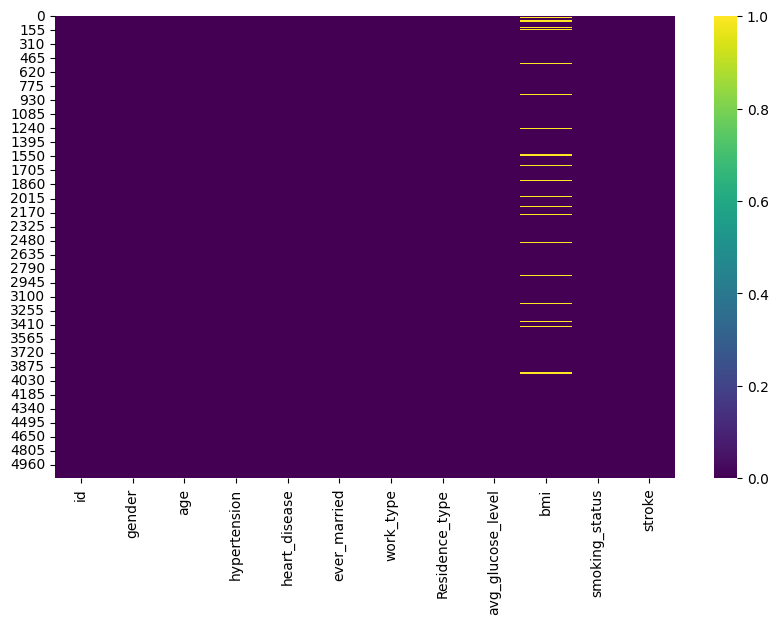

In [104]:
plt.figure(figsize=(10,6))
sns.heatmap(df.isnull(),cmap='viridis')
plt.show()

In [105]:
df.duplicated().sum()

np.int64(0)

In [106]:
# Summary statistics (helps spot impossible values)
df.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612731,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [107]:
# Unique values in a column (helps find inconsistent spellings)
df.nunique()

,0
id,5110
gender,3
age,83
hypertension,2
heart_disease,2
ever_married,2
work_type,5
Residence_type,2
avg_glucose_level,3979
bmi,418


In [108]:
# Unique values in a column (helps find inconsistent spellings)
df["gender"].unique()
#jastai male ko MALE or MaLe huna sakthyo tyo herna lai ho

array(['Male', 'Female', 'Other'], dtype=object)

##seems like datas are clean except for some bim's being missing

Data is clean when:

✅ No missing values (or missing values have been handled properly)

✅ No duplicate records (or unnecessary duplicates have been removed)

✅ Correct data types (e.g., age should be an integer, date should be a datetime)

✅ Consistent formatting (e.g., "Male", "male", and "MALE" should be standardized)

✅ No invalid values (e.g., age = -5, salary = "abc")

✅ Outliers have been checked (depending on the problem, some outliers are valid, others are errors)

#Univariate Analysis

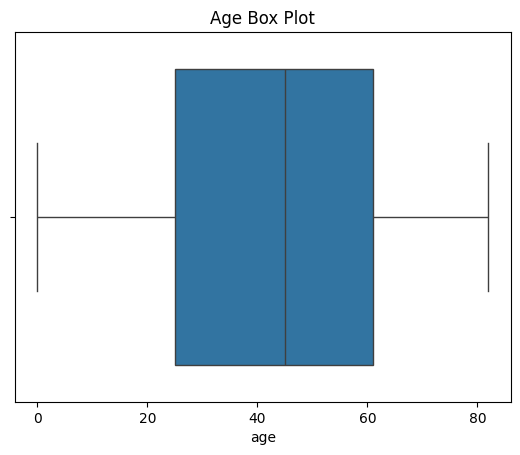

In [109]:
sns.boxplot(df["age"].dropna(), orient="h")
plt.title("Age Box Plot")
plt.show()

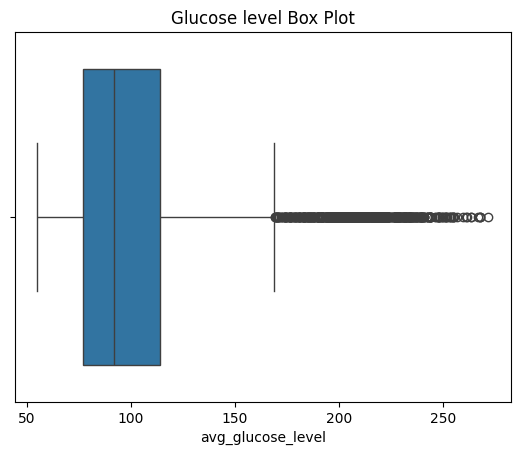

In [110]:
sns.boxplot(df["avg_glucose_level"].dropna(), orient="h")
plt.title("Glucose level Box Plot")
plt.show()

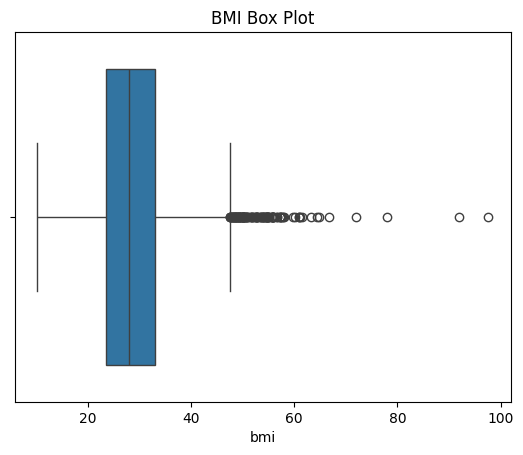

In [111]:
sns.boxplot(df["bmi"].dropna(), orient="h")
plt.title("BMI Box Plot")
plt.show()

###Boxplots revealed several outliers in the BMI and average glucose level columns. Since these values are medically plausible and represent actual patients rather than data entry errors, they were retained in the dataset.
You only remove outliers when:

they are obvious mistakes (e.g., Age = 500),

or you have a justified preprocessing strategy for modelling.

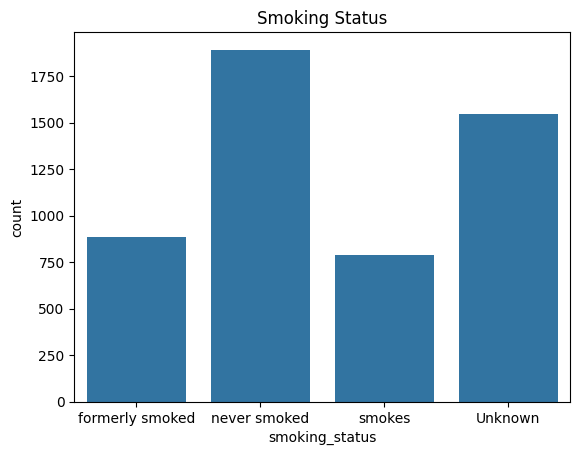

In [112]:

sns.countplot(data=df, x="smoking_status")
plt.title("Smoking Status")
plt.show()

In [113]:
df["smoking_status"].value_counts()

,count
smoking_status,
never smoked,1892
Unknown,1544
formerly smoked,885
smokes,789


The smoking_status column contains a large number of Unknown values. This indicates that smoking information was not recorded for many patients. Since this is an EDA phase, these values were retained to accurately represent the dataset.

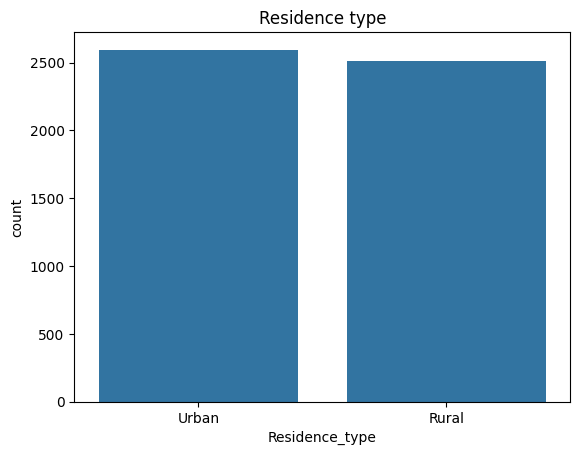

In [114]:
sns.countplot(data=df, x="Residence_type")
plt.title("Residence type")
plt.show()

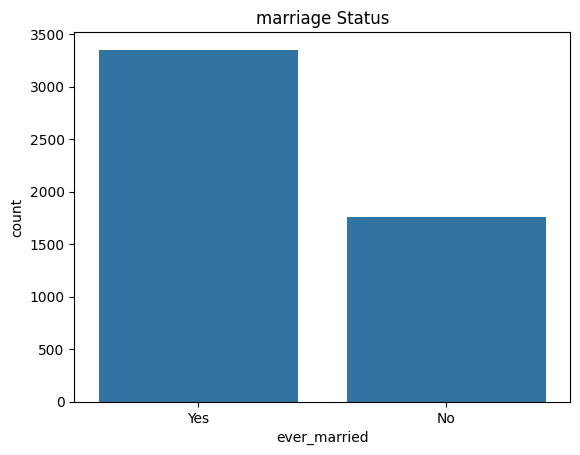

In [115]:
sns.countplot(data=df, x="ever_married")
plt.title("marriage Status")
plt.show()

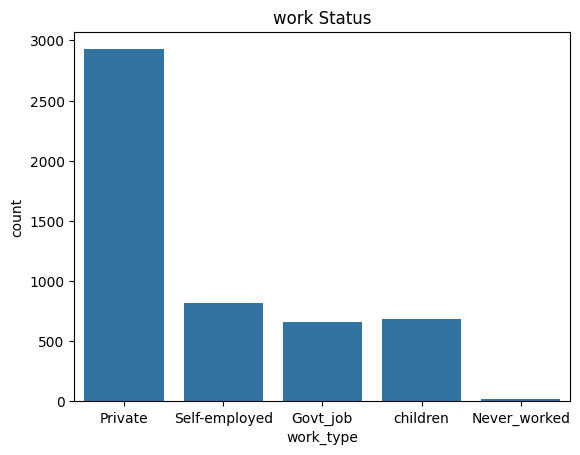

In [116]:
sns.countplot(data=df, x="work_type")
plt.title("work Status")
plt.show()

# Bivariate Analysis

Gender vs stroke

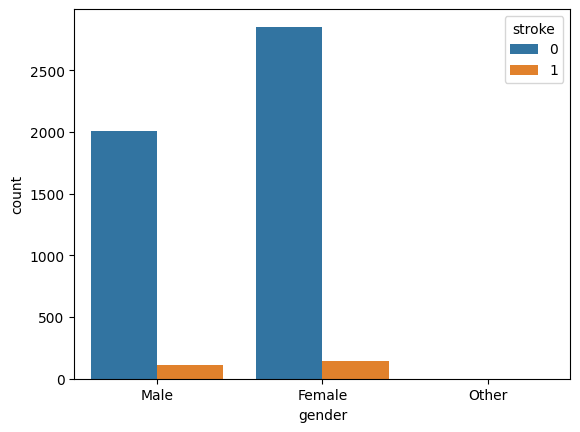

In [117]:
sns.countplot(
    data=df,
    x="gender",
    hue="stroke"
)
plt.show()

age vs stroke

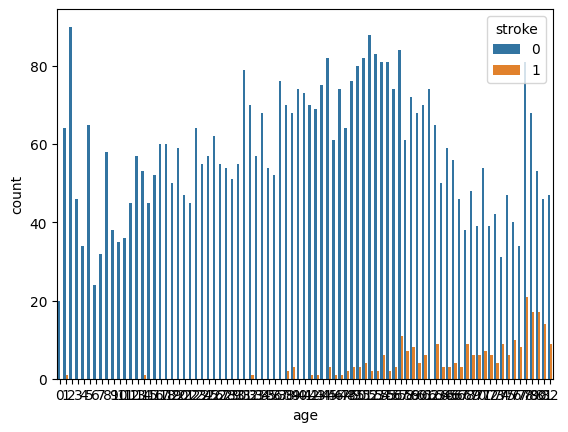

In [118]:
sns.countplot(
    data=df,
    x="age",
    hue="stroke"
)
plt.show()

# bin banayena bhane yesto hunxa

In [127]:
bins = [0, 12, 19, 39, 59, 100]
labels = ['Child', 'Teen', 'Adult', 'Middle-aged', 'Senior']

df['age_Bin'] = pd.cut(df['age'].dropna(), bins=bins, labels=labels)

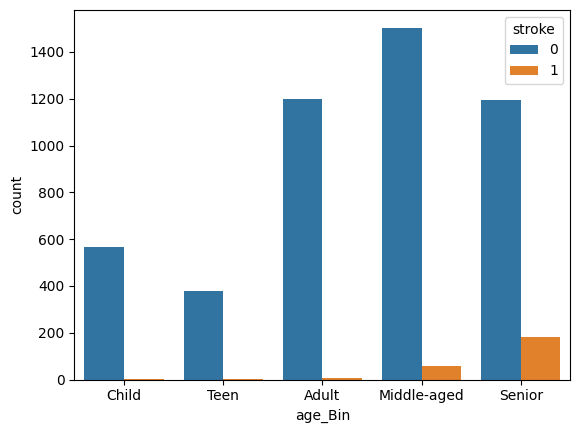

In [129]:
sns.countplot(
    data=df,
    x="age_Bin",
    hue="stroke"
)
plt.show()

hypertension vs stroke

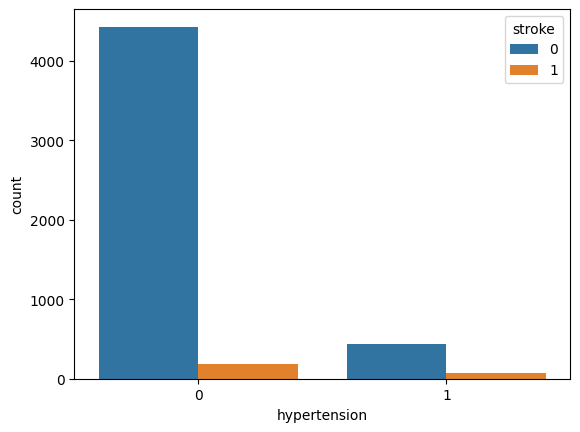

In [119]:
sns.countplot(
    data=df,
    x="hypertension",
    hue="stroke"
)
plt.show()

heart desease vs stroke

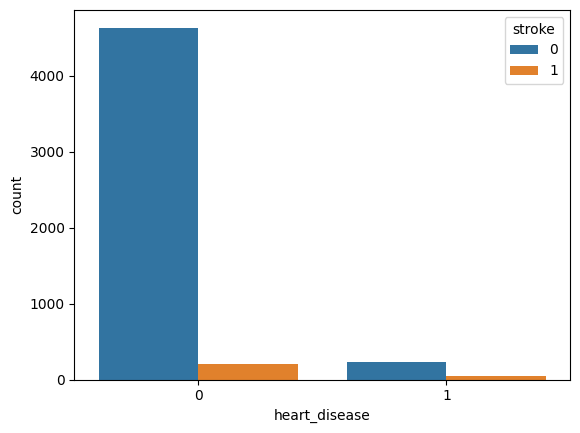

In [120]:
sns.countplot(
    data=df,
    x="heart_disease",
    hue="stroke"
)
plt.show()

marriage vs stroke

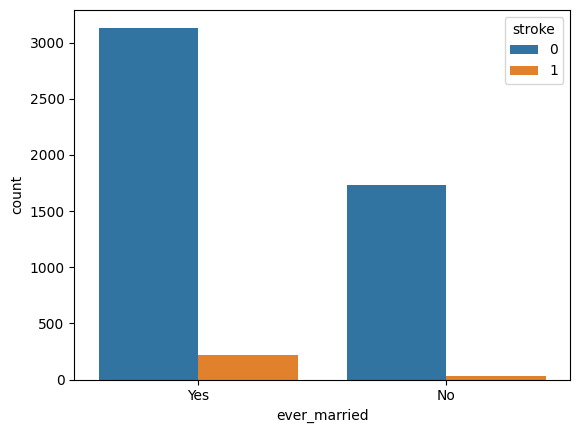

In [121]:
sns.countplot(
    data=df,
    x="ever_married",
    hue="stroke"
)
plt.show()

work type vs stroke

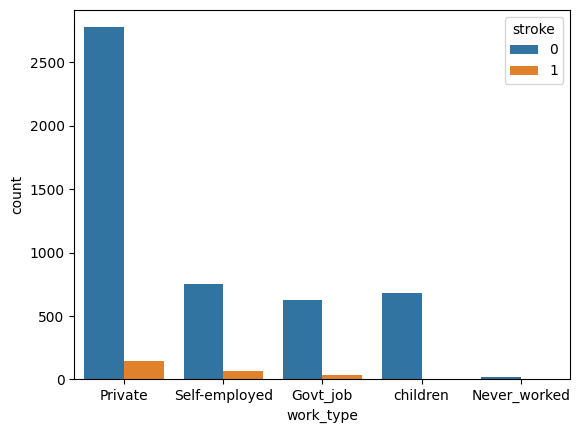

In [122]:
sns.countplot(
    data=df,
    x="work_type",
    hue="stroke"
)
plt.show()

Residence_type vs stroke

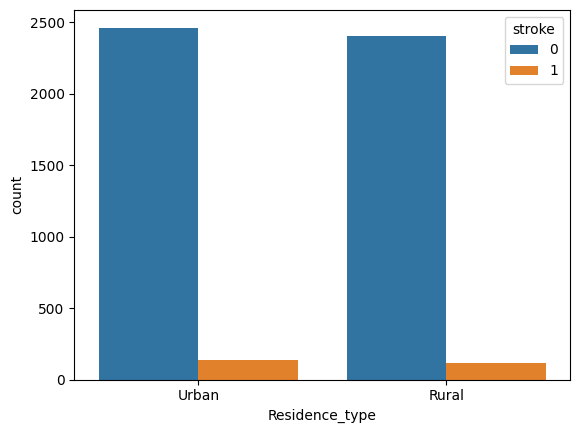

In [123]:
sns.countplot(
    data=df,
    x="Residence_type",
    hue="stroke"
)
plt.show()

avg_glucose_level vs stroke

In [135]:
bins = [50, 100, 150, 200, 250, 300]

df['glu_Bin'] = pd.cut(df['avg_glucose_level'].dropna(), bins=bins)

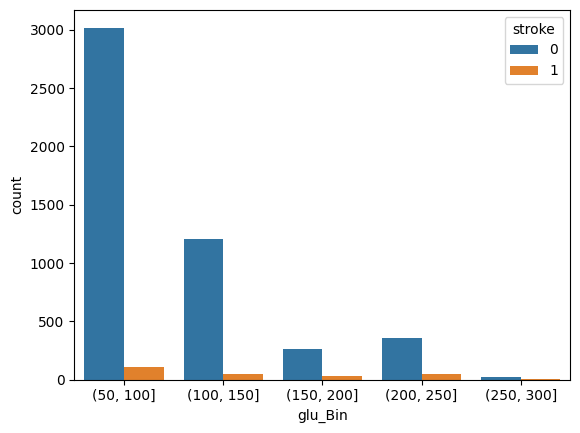

In [136]:
sns.countplot(
    data=df,
    x="glu_Bin",
    hue="stroke"
)
plt.show()

bmi vs stroke

In [137]:
bins = [0, 18.5, 25, 30, 100]
labelss = ["Underweight", "Normal", "Overweight", "Obese"]

df["bmi_group"] = pd.cut(df["bmi"], bins=bins, labels=labelss)

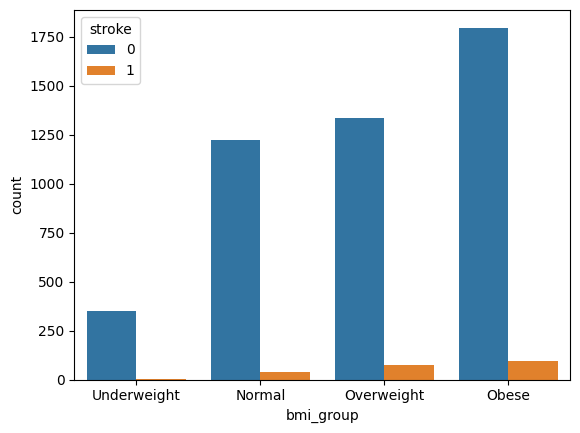

In [138]:
sns.countplot(
    data=df,
    x="bmi_group",
    hue="stroke"
)
plt.show()

Smoke vs stroke

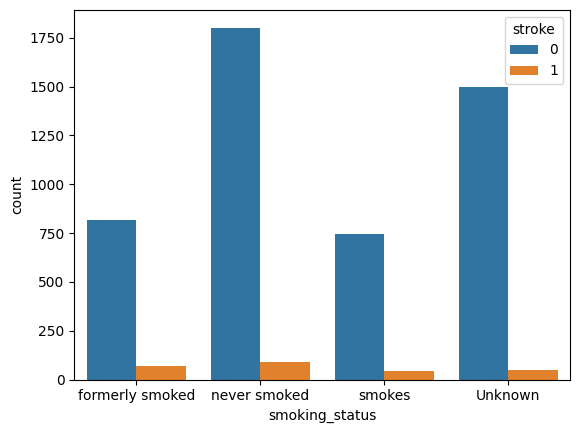

In [126]:
sns.countplot(
    data=df,
    x="smoking_status",
    hue="stroke"
)
plt.show()

#MultiVariate Analysis

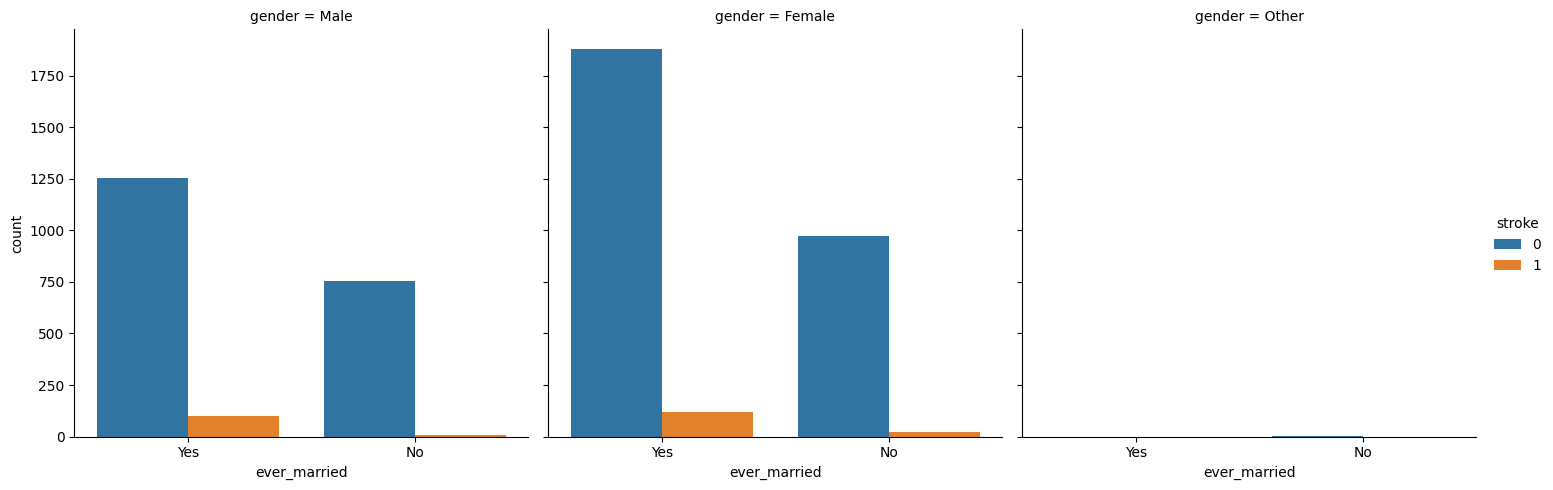

In [140]:
sns.catplot(
    data=df,
    x="ever_married",
    hue="stroke",
    col="gender",
    kind="count"
)
plt.show()

In [142]:
print(df["gender"].value_counts())

gender
Female    2994
Male      2115
Other        1
Name: count, dtype: int64


after i saw this i found that there is only 1 sex others its better that i drop it
###(yo mathi nai garna parni ho)

In [143]:
df = df[df["gender"] != "Other"]

In [144]:
print(df["gender"].value_counts())

gender
Female    2994
Male      2115
Name: count, dtype: int64


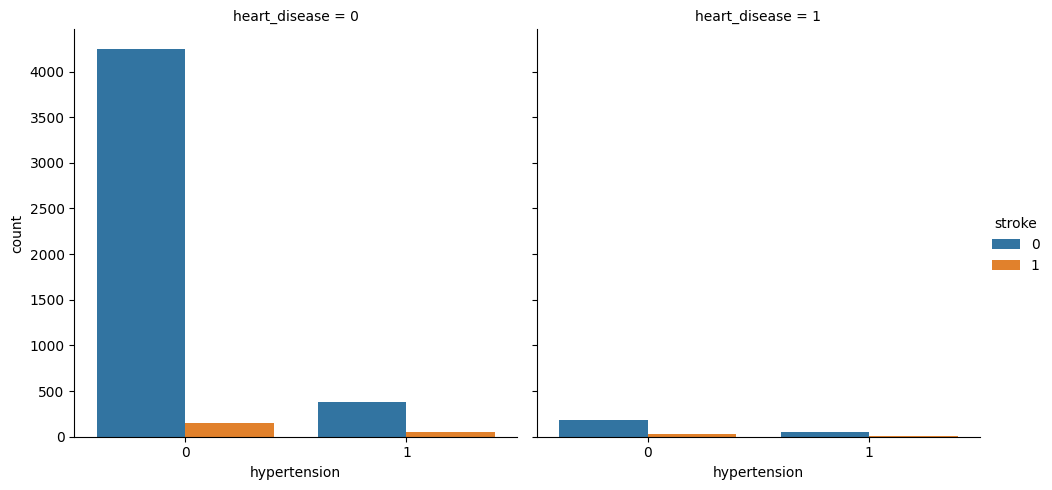

In [145]:
sns.catplot(
    data=df,
    x="hypertension",
    hue="stroke",
    col="heart_disease",
    kind="count"
)

plt.show()

#Correlation heatmap

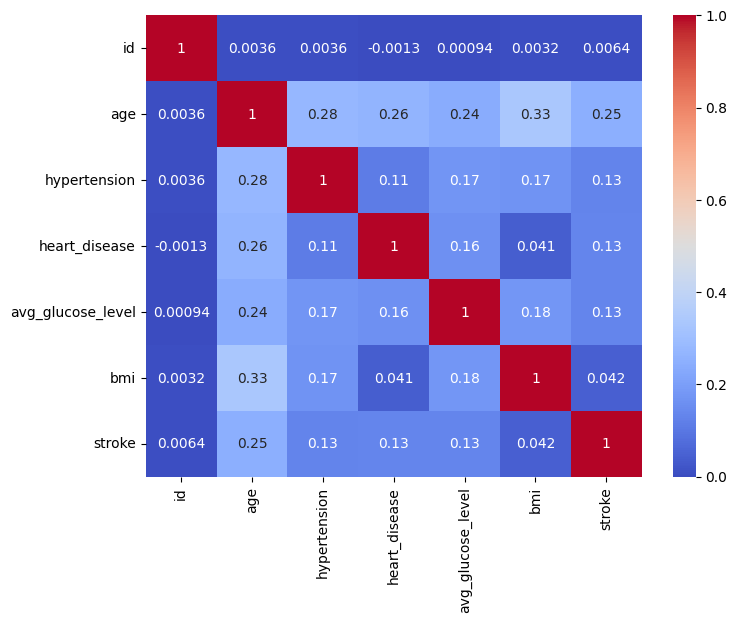

In [146]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

The heatmap indicates that age is the most influential feature related to stroke, while hypertension, heart disease, and average glucose level show weaker positive relationships.

In [147]:
df.corr(numeric_only=True)["stroke"].sort_values(ascending=False)

,stroke
stroke,1.000000
age,0.245225
heart_disease,0.134905
avg_glucose_level,0.131991
hypertension,0.127891
bmi,0.042341
id,0.006430


#Summary of my EDA
1.BMI had missing values that were imputed with the median.

2.The dataset is imbalanced, with many more non-stroke than stroke cases.

3.Age showed the strongest positive association with stroke among the numerical features.

4.Hypertension, heart disease, and higher glucose levels were associated with increased stroke occurrence.

5.Most numerical correlations with stroke were weak.

6.The single "Other" gender record was removed because it represented only one observation.

7.Boxplots revealed several outliers in the BMI and average glucose level columns. Since these values are medically plausible and represent actual patients rather than data entry errors, they were retained in the dataset.